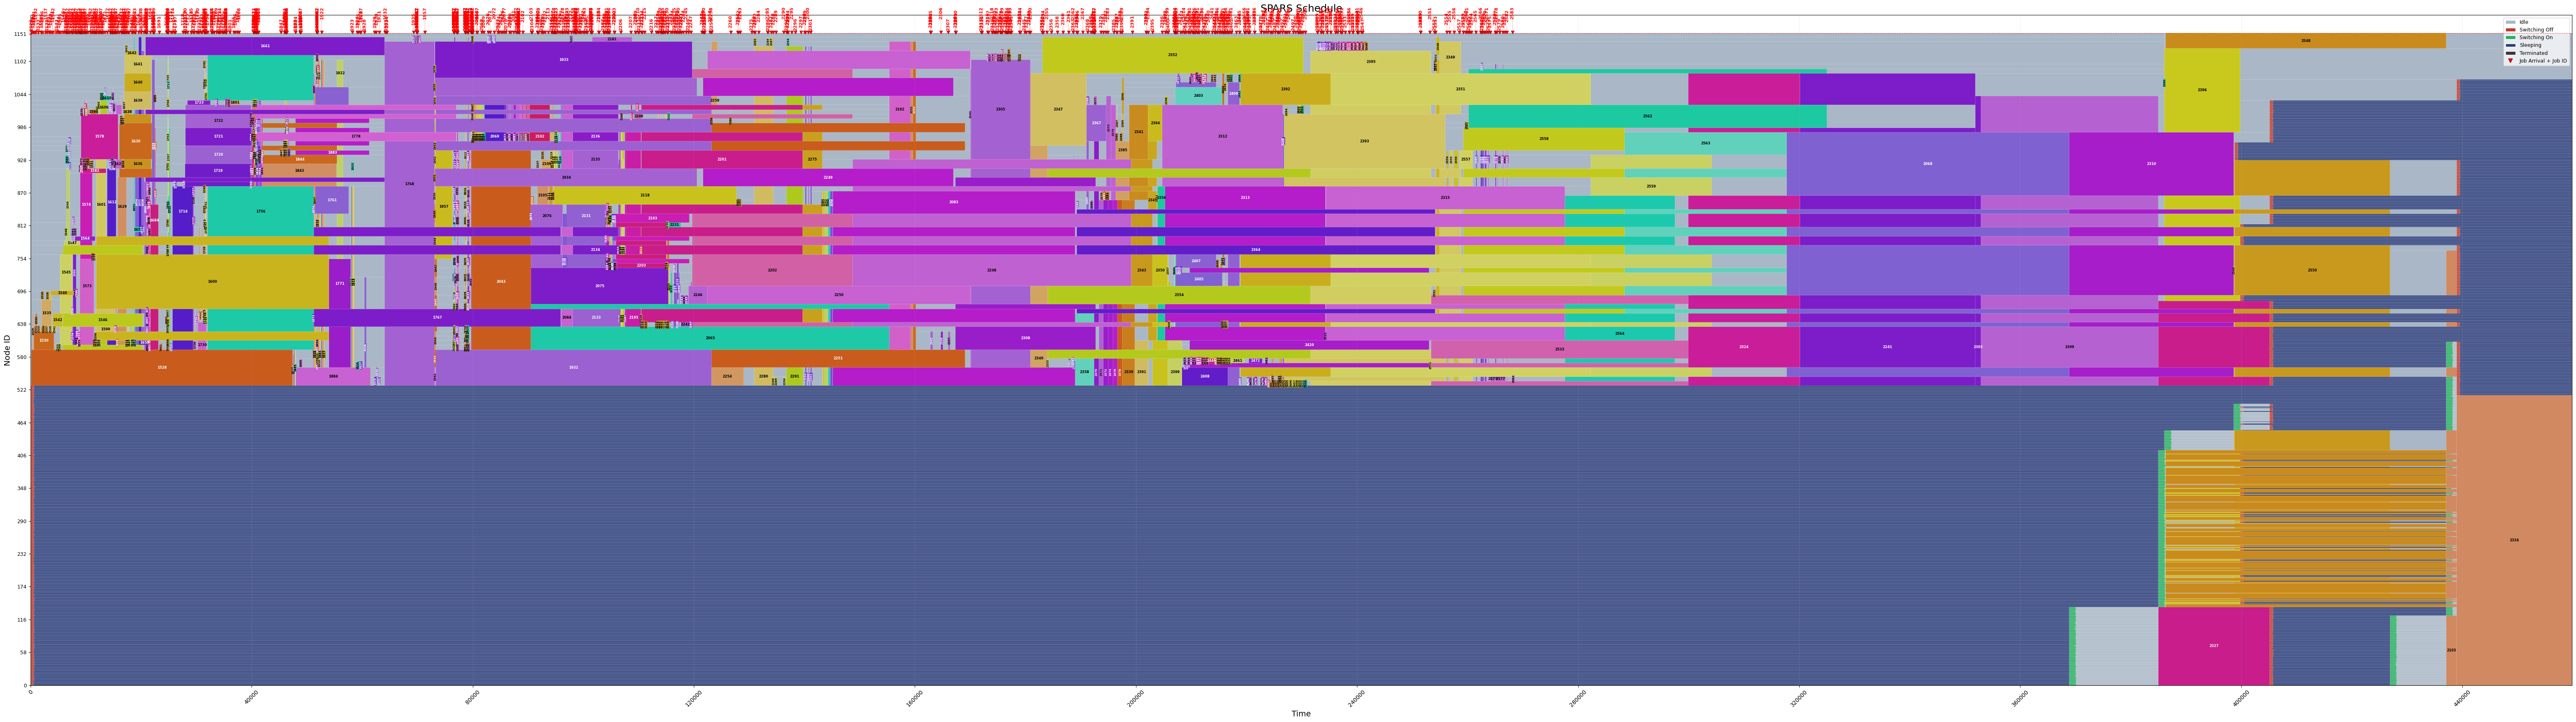

Gantt chart saved to: plots/SNF MP Cerit 3600.png


In [1]:
import os
import colorsys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.collections import PatchCollection
from matplotlib.patches import Patch, Rectangle
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator


def _hue_is_reserved(hue):
    for center, half_width in RESERVED_HUES:
        difference = abs(hue - center)
        difference = min(difference, 1.0 - difference)

        if difference < half_width:
            return True

    return False


def _build_job_palette(number_of_colors=100):
    palette = []
    hue = 0.0
    step = 1.0 / (number_of_colors * 1.5)
    saturation_cycle = [0.75, 0.55]
    lightness_cycle = [0.45, 0.60]

    while len(palette) < number_of_colors:
        hue = (hue + step) % 1.0

        if _hue_is_reserved(hue):
            continue

        index = len(palette)
        saturation = saturation_cycle[index % len(saturation_cycle)]
        lightness = lightness_cycle[index % len(lightness_cycle)]
        red, green, blue = colorsys.hls_to_rgb(hue, lightness, saturation)
        palette.append((red, green, blue))

    return palette


def parse_nodes(value):
    if value is None:
        return []

    if isinstance(value, (list, tuple, np.ndarray)):
        return [int(node_id) for node_id in value]

    if pd.isna(value):
        return []

    text = str(value).strip()

    if not text:
        return []

    return [int(node_id) for node_id in text.split()]


def parse_boolean(value):
    if isinstance(value, bool):
        return value

    if value is None or pd.isna(value):
        return False

    return str(value).strip().lower() in {"true", "1", "yes"}


def read_timeline(file_path):
    data = pd.read_csv(file_path)

    node_column = "allocated_resources" if "allocated_resources" in data.columns else "nodes"
    start_column = "starting_time" if "starting_time" in data.columns else "start_time"
    type_column = "type" if "type" in data.columns else "state"

    required_columns = {node_column, start_column, "finish_time", "job_id"}
    missing_columns = required_columns - set(data.columns)

    if missing_columns:
        raise KeyError(f"Missing required columns: {sorted(missing_columns)}")

    has_submission_time = "submission_time" in data.columns
    timeline = []

    for _, row in data.iterrows():
        nodes = parse_nodes(row[node_column])

        if not nodes:
            continue

        start_time = float(row[start_column])
        finish_time = float(row["finish_time"])

        if finish_time <= start_time:
            continue

        entry = {
            "starting_time": start_time,
            "finish_time": finish_time,
            "allocated_resources": nodes,
            "type": row.get(type_column),
            "job_id": int(row["job_id"]),
            "terminated": parse_boolean(row.get("terminated", False)),
        }

        if has_submission_time and pd.notna(row["submission_time"]):
            entry["submission_time"] = float(row["submission_time"])

        timeline.append(entry)

    return timeline


def contiguous_groups(nodes):
    nodes = sorted(set(nodes))

    if not nodes:
        return []

    groups = []
    group_start = nodes[0]
    previous_node = nodes[0]

    for node_id in nodes[1:]:
        if node_id == previous_node + 1:
            previous_node = node_id
            continue

        groups.append((group_start, previous_node - group_start + 1))
        group_start = node_id
        previous_node = node_id

    groups.append((group_start, previous_node - group_start + 1))
    return groups


def build_job_colors(timeline):
    job_ids = sorted({
        event["job_id"]
        for event in timeline
        if event["job_id"] > 0
    })

    return {
        job_id: JOB_PALETTE[index % len(JOB_PALETTE)]
        for index, job_id in enumerate(job_ids)
    }


def get_text_color(background_color):
    if isinstance(background_color, str):
        hexadecimal = background_color.lstrip("#")
        red, green, blue = (
            int(hexadecimal[index:index + 2], 16) / 255.0
            for index in (0, 2, 4)
        )
    else:
        red, green, blue = background_color[:3]

    luminance = 0.299 * red + 0.587 * green + 0.114 * blue
    return "white" if luminance < 0.5 else "black"


def plot_job_intervals(ax, timeline, job_colors, max_time):
    rectangles = []
    rectangle_colors = []
    best_label_by_job = {}

    for event in timeline:
        start_time = float(event["starting_time"])
        finish_time = float(event["finish_time"])
        duration = finish_time - start_time

        if duration <= 0:
            continue

        job_id = event["job_id"]

        if event["terminated"]:
            color = TERMINATED_COLOR
        elif job_id in STATE_COLORS:
            color = STATE_COLORS[job_id]
        else:
            color = job_colors[job_id]

        groups = contiguous_groups(event["allocated_resources"])

        for node_start, node_count in groups:
            rectangles.append(Rectangle(
                (start_time, node_start),
                duration,
                node_count,
            ))
            rectangle_colors.append(color)

        if SHOW_JOB_LABELS and job_id > 0 and groups:
            largest_group = max(groups, key=lambda group: group[1])

            candidate = {
                "job_id": job_id,
                "start_time": start_time,
                "finish_time": finish_time,
                "node_start": largest_group[0],
                "node_count": largest_group[1],
                "color": color,
                "score": duration * largest_group[1],
            }

            previous = best_label_by_job.get(job_id)

            if previous is None or candidate["score"] > previous["score"]:
                best_label_by_job[job_id] = candidate

    if rectangles:
        collection = PatchCollection(
            rectangles,
            facecolors=rectangle_colors,
            edgecolors="white",
            linewidths=0.12,
            rasterized=True,
        )
        ax.add_collection(collection)

    if not SHOW_JOB_LABELS:
        return

    thin_duration = max_time * THIN_JOB_LABEL_THRESHOLD

    for candidate in best_label_by_job.values():
        duration = candidate["finish_time"] - candidate["start_time"]
        is_thin = duration < thin_duration

        x = (candidate["start_time"] + candidate["finish_time"]) / 2.0
        y = candidate["node_start"] + candidate["node_count"] / 2.0

        ax.text(
            x,
            y,
            str(candidate["job_id"]),
            ha="center",
            va="center",
            color=get_text_color(candidate["color"]),
            fontsize=THIN_JOB_LABEL_FONTSIZE if is_thin else JOB_LABEL_FONTSIZE,
            fontweight="bold",
            rotation=90 if is_thin else 0,
            rotation_mode="anchor",
            clip_on=True,
            zorder=6,
            bbox={
                "facecolor": candidate["color"],
                "edgecolor": "none",
                "alpha": 0.75,
                "pad": 0.15,
            } if is_thin else None,
        )


def plot_arrivals(ax, timeline, num_nodes):
    if not SHOW_JOB_ARRIVALS:
        return

    arrival_times = {}

    for event in timeline:
        job_id = event["job_id"]

        if job_id > 0 and "submission_time" in event:
            arrival_times.setdefault(job_id, float(event["submission_time"]))

    if not arrival_times:
        print("Warning: no submission_time values were found for positive job IDs.")
        return

    sorted_arrivals = sorted(
        arrival_times.items(),
        key=lambda item: (item[1], item[0]),
    )

    marker_y = num_nodes + 1.5
    x_values = [submission_time for _, submission_time in sorted_arrivals]
    y_values = [marker_y] * len(sorted_arrivals)

    ax.scatter(
        x_values,
        y_values,
        marker="v",
        s=ARRIVAL_MARKER_SIZE,
        color="red",
        edgecolors="darkred",
        linewidths=0.5,
        zorder=10,
        clip_on=False,
    )

    for index, (job_id, submission_time) in enumerate(sorted_arrivals):
        level = index % ARRIVAL_LABEL_LEVELS
        label_y = marker_y + 3 + level * 5

        ax.text(
            submission_time,
            label_y,
            str(job_id),
            ha="center",
            va="bottom",
            color="red",
            fontsize=ARRIVAL_LABEL_FONTSIZE,
            fontweight="bold",
            rotation=90,
            clip_on=False,
            zorder=11,
        )

        ax.plot(
            [submission_time, submission_time],
            [marker_y + 0.5, label_y - 0.5],
            color="red",
            linewidth=0.35,
            alpha=0.6,
            zorder=9,
            clip_on=False,
        )


def plot_timeline(ax, timeline, title, max_time, num_nodes):
    job_colors = build_job_colors(timeline)

    plot_job_intervals(
        ax=ax,
        timeline=timeline,
        job_colors=job_colors,
        max_time=max_time,
    )

    plot_arrivals(
        ax=ax,
        timeline=timeline,
        num_nodes=num_nodes,
    )

    ax.set_xlim(0, max_time)

    top_limit = (
        num_nodes + ARRIVAL_BAND_HEIGHT
        if SHOW_JOB_ARRIVALS
        else num_nodes
    )
    ax.set_ylim(0, top_limit)

    if SHOW_JOB_ARRIVALS:
        ax.axhline(
            y=num_nodes,
            color="red",
            linewidth=0.8,
            linestyle="--",
            alpha=0.6,
            zorder=8,
        )

        ax.text(
            0,
            num_nodes + 1.5,
            "Job arrivals",
            color="red",
            fontsize=9,
            fontweight="bold",
            ha="left",
            va="center",
            zorder=12,
        )

    ax.set_title(title, fontsize=18)
    ax.set_xlabel("Time", fontsize=14)
    ax.set_ylabel("Node ID", fontsize=14)

    ax.xaxis.set_major_locator(MaxNLocator(nbins=MAX_X_TICKS))
    ax.tick_params(axis="x", labelrotation=45, labelsize=10)

    y_step = max(1, int(np.ceil(num_nodes / MAX_Y_TICKS)))
    y_ticks = list(range(0, num_nodes, y_step))

    if not y_ticks or y_ticks[-1] != num_nodes - 1:
        y_ticks.append(num_nodes - 1)

    ax.set_yticks(y_ticks)
    ax.tick_params(axis="y", labelsize=9)
    ax.grid(axis="x", alpha=0.25, linewidth=0.5)

    state_labels = {
        -1: "Idle",
        -2: "Switching Off",
        -3: "Switching On",
        -4: "Sleeping",
    }

    legend_handles = [
        Patch(
            facecolor=STATE_COLORS[state_id],
            edgecolor="white",
            label=state_label,
        )
        for state_id, state_label in state_labels.items()
    ]

    legend_handles.append(Patch(
        facecolor=TERMINATED_COLOR,
        edgecolor="white",
        label="Terminated",
    ))

    if SHOW_JOB_ARRIVALS:
        legend_handles.append(Line2D(
            [0],
            [0],
            marker="v",
            color="red",
            markerfacecolor="red",
            markeredgecolor="darkred",
            markersize=7,
            linestyle="None",
            label="Job Arrival + Job ID",
        ))

    ax.legend(
        handles=legend_handles,
        loc="upper right",
        fontsize=9,
        framealpha=0.75,
    )


def main():
    timeline = read_timeline(NODE_LOG_PATH)

    if not timeline:
        raise RuntimeError("No valid timeline entries were found.")

    if NUM_NODES is None:
        num_nodes = max(
            max(event["allocated_resources"])
            for event in timeline
        ) + 1
    else:
        num_nodes = int(NUM_NODES)

    max_time = max(event["finish_time"] for event in timeline)

    output_directory = os.path.dirname(OUTPUT_PATH)

    if output_directory:
        os.makedirs(output_directory, exist_ok=True)

    fig, ax = plt.subplots(figsize=FIGURE_SIZE)

    plot_timeline(
        ax=ax,
        timeline=timeline,
        title=TITLE,
        max_time=max_time,
        num_nodes=num_nodes,
    )

    fig.tight_layout()

    fig.savefig(
        OUTPUT_PATH,
        dpi=OUTPUT_DPI,
        bbox_inches="tight",
        pad_inches=0.15,
    )

    plt.show()
    print(f"Gantt chart saved to: {OUTPUT_PATH}")


# ============================================================
# Parameters
# ============================================================

NODE_LOG_PATH = "results/25june/AOBA-A/SDSC_1000-1999/Test-w1-0.20_w2-0.25/node_log.csv"
OUTPUT_PATH = "plots/SNF MP Cerit 3600.png"
TITLE = "SPARS Schedule"

NUM_NODES = 1152
FIGURE_SIZE = (64, 18)
OUTPUT_DPI = 180

SHOW_JOB_LABELS = True
JOB_LABEL_FONTSIZE = 6
THIN_JOB_LABEL_FONTSIZE = 5

# Blocks thinner than this fraction of the complete x-axis use vertical labels.
THIN_JOB_LABEL_THRESHOLD = 0.002

SHOW_JOB_ARRIVALS = True
ARRIVAL_LABEL_FONTSIZE = 8
ARRIVAL_MARKER_SIZE = 32
ARRIVAL_BAND_HEIGHT = 32
ARRIVAL_LABEL_LEVELS = 5

MAX_X_TICKS = 14
MAX_Y_TICKS = 20

STATE_COLORS = {
    -1: "#A9B7C6",
    -2: "#C0392B",
    -3: "#27AE60",
    -4: "#2C3E7A",
}

TERMINATED_COLOR = "#3D3535"

RESERVED_HUES = [
    (0.00, 0.06),
    (0.33, 0.13),
    (0.55, 0.07),
    (0.60, 0.06),
    (0.65, 0.06),
]

JOB_PALETTE = _build_job_palette(100)


if __name__ == "__main__":
    main()